In [1]:
import pandas as pd 
import numpy as np

C:\Users\Admin\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [74]:
df= pd.read_csv(r"E:\Data\Data Analytics\Python\DAY_30_PROJECT\zomato.csv")
print(df).head(5)

                                                     url  \
0      https://www.zomato.com/bangalore/jalsa-banasha...   
1      https://www.zomato.com/bangalore/spice-elephan...   
2      https://www.zomato.com/SanchurroBangalore?cont...   
3      https://www.zomato.com/bangalore/addhuri-udupi...   
4      https://www.zomato.com/bangalore/grand-village...   
...                                                  ...   
51712  https://www.zomato.com/bangalore/best-brews-fo...   
51713  https://www.zomato.com/bangalore/vinod-bar-and...   
51714  https://www.zomato.com/bangalore/plunge-sherat...   
51715  https://www.zomato.com/bangalore/chime-sherato...   
51716  https://www.zomato.com/bangalore/the-nest-the-...   

                                                 address  \
0      942, 21st Main Road, 2nd Stage, Banashankari, ...   
1      2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...   
2      1112, Next to KIMS Medical College, 17th Cross...   
3      1st Floor, Annakuteera, 3rd Stag

AttributeError: 'NoneType' object has no attribute 'head'

In [4]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [6]:
df.isna().sum()  #To check the count of null values

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [7]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [8]:
df1=df.copy()
print(df1.head(2))  #create a copy of your dataset

                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   

                                             address            name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...           Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...  Spice Elephant   

  online_order book_table   rate  votes                           phone  \
0          Yes        Yes  4.1/5    775  080 42297555\r\n+91 9743772233   
1          Yes         No  4.1/5    787                    080 41714161   

       location      rest_type  \
0  Banashankari  Casual Dining   
1  Banashankari  Casual Dining   

                                          dish_liked  \
0  Pasta, Lunch Buffet, Masala Papad, Paneer Laja...   
1  Momos, Lunch Buffet, Chocolate Nirvana, Thai G...   

                         cuisines approx_cost(for two people)  \
0  North Indian, Mughlai, Chinese                  

In [9]:
df1.columns= df1.columns.str.lower()

In [10]:
df1= df1.drop(columns = ['url','dish_liked','phone'])
print(df1.columns)

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'approx_cost(for two people)',
       'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)'],
      dtype='str')


In [11]:
df1.shape

(51717, 14)

In [12]:
df1.rename(columns = {'approx_cost(for two people)': 'approx_cost','listed_in(type)':'meal_type','listed_in(city)': 'area'},inplace= True)
df1.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'approx_cost', 'reviews_list',
       'menu_item', 'meal_type', 'area'],
      dtype='str')

In [13]:
df1['rate'].unique()

<ArrowStringArray>
[ '4.1/5',  '3.8/5',  '3.7/5',  '3.6/5',  '4.6/5',  '4.0/5',  '4.2/5',
  '3.9/5',  '3.1/5',  '3.0/5',  '3.2/5',  '3.3/5',  '2.8/5',  '4.4/5',
  '4.3/5',    'NEW',  '2.9/5',  '3.5/5',      nan,  '2.6/5', '3.8 /5',
  '3.4/5',  '4.5/5',  '2.5/5',  '2.7/5',  '4.7/5',  '2.4/5',  '2.2/5',
  '2.3/5', '3.4 /5',      '-', '3.6 /5',  '4.8/5', '3.9 /5', '4.2 /5',
 '4.0 /5', '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
 '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5', '4.3 /5',
 '4.4 /5',  '4.9/5',  '2.1/5',  '2.0/5',  '1.8/5', '4.6 /5', '4.9 /5',
 '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5', '2.1 /5', '2.2 /5',
 '2.0 /5', '1.8 /5']
Length: 65, dtype: str

In [14]:
df1["rate"] = (
    df1["rate"]
    .astype(str)
    .str.replace("/5", "", regex=False)   
    .str.strip()
    .replace(["NEW", "-", "", "nan"], np.nan)
)

df1["rate"] = pd.to_numeric(df1["rate"], errors="coerce")

In [15]:
df1['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [16]:
df1['rate'].astype(float)

0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    NaN
51714    NaN
51715    4.3
51716    3.4
Name: rate, Length: 51717, dtype: float64

In [17]:
df1['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [18]:
df1['approx_cost'].unique()

<ArrowStringArray>
[  '800',   '300',   '600',   '700',   '550',   '500',   '450',   '650',
   '400',   '900',   '200',   '750',   '150',   '850',   '100', '1,200',
   '350',   '250',   '950', '1,000', '1,500', '1,300',   '199',    '80',
 '1,100',   '160', '1,600',   '230',   '130',    '50',   '190', '1,700',
     nan, '1,400',   '180', '1,350', '2,200', '2,000', '1,800', '1,900',
   '330', '2,500', '2,100', '3,000', '2,800', '3,400',    '40', '1,250',
 '3,500', '4,000', '2,400', '2,600',   '120', '1,450',   '469',    '70',
 '3,200',    '60',   '560',   '240',   '360', '6,000', '1,050', '2,300',
 '4,100', '5,000', '3,700', '1,650', '2,700', '4,500',   '140']
Length: 71, dtype: str

In [19]:
df1['approx_cost']= df1['approx_cost'].str.replace(",","", regex=False)
df1['approx_cost']= pd.to_numeric(df1['approx_cost'])

In [20]:
df1['approx_cost'].unique()

array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700.,   nan, 1400.,  180., 1350.,
       2200., 2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800.,
       3400.,   40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,
        469.,   70., 3200.,   60.,  560.,  240.,  360., 6000., 1050.,
       2300., 4100., 5000., 3700., 1650., 2700., 4500.,  140.])

In [29]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   address       51717 non-null  str    
 1   name          51717 non-null  str    
 2   online_order  51717 non-null  str    
 3   book_table    51717 non-null  str    
 4   rate          41665 non-null  float64
 5   votes         51717 non-null  int64  
 6   location      51696 non-null  str    
 7   rest_type     51490 non-null  str    
 8   cuisines      51672 non-null  str    
 9   approx_cost   51371 non-null  float64
 10  reviews_list  51717 non-null  str    
 11  menu_item     51717 non-null  str    
 12  meal_type     51717 non-null  str    
 13  area          51717 non-null  str    
dtypes: float64(2), int64(1), str(11)
memory usage: 529.0 MB


In [36]:
median_cost = df1['approx_cost'].median()
df1["approx_cost"]=df1['approx_cost'].fillna(median_cost)
median_rate= df1['rate'].median()
df1['rate']= df['rate'].fillna(median_rate)


In [37]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   address       51717 non-null  str    
 1   name          51717 non-null  str    
 2   online_order  51717 non-null  str    
 3   book_table    51717 non-null  str    
 4   rate          51717 non-null  float64
 5   votes         51717 non-null  int64  
 6   location      51696 non-null  str    
 7   rest_type     51490 non-null  str    
 8   cuisines      51672 non-null  str    
 9   approx_cost   51717 non-null  float64
 10  reviews_list  51717 non-null  str    
 11  menu_item     51717 non-null  str    
 12  meal_type     51717 non-null  str    
 13  area          51717 non-null  str    
dtypes: float64(2), int64(1), str(11)
memory usage: 529.0 MB


In [38]:
location_mode = df1['location'].mode()[0]
df1['location']= df1["location"].fillna(location_mode)
rest_mode = df['rest_type'].mode()[0]
df1['rest_type']= df1['rest_type'].fillna(rest_mode)
cuisines_mode = df['cuisines'].mode()[0]
df1['cuisines']= df1['cuisines'].fillna(cuisines_mode)


In [39]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   address       51717 non-null  str    
 1   name          51717 non-null  str    
 2   online_order  51717 non-null  str    
 3   book_table    51717 non-null  str    
 4   rate          51717 non-null  float64
 5   votes         51717 non-null  int64  
 6   location      51717 non-null  str    
 7   rest_type     51717 non-null  str    
 8   cuisines      51717 non-null  str    
 9   approx_cost   51717 non-null  float64
 10  reviews_list  51717 non-null  str    
 11  menu_item     51717 non-null  str    
 12  meal_type     51717 non-null  str    
 13  area          51717 non-null  str    
dtypes: float64(2), int64(1), str(11)
memory usage: 529.0 MB


# Exploratory Data Analysis (EDA)

In [41]:
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set_style('darkgrid')  # style for all our plots
plt.rcParams['figure.figsize'] = (10,7) # Default figure size
print("plotting libraries imported and styles set")

plotting libraries imported and styles set


## Q) what is the distribution of restaurant ratings?

In [42]:
# A Histrogram is the perfect Plot for this.

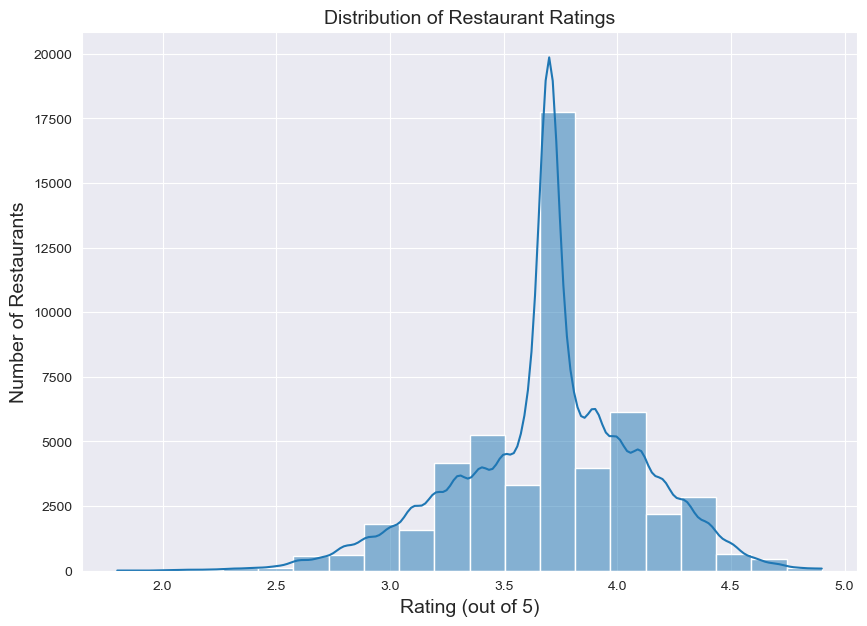

In [43]:
sns.histplot(df1['rate'], bins = 20 , kde= True)
plt.title("Distribution of Restaurant Ratings",fontsize = 14)
plt.xlabel("Rating (out of 5)", fontsize = 14)
plt.ylabel("Number of Restaurants", fontsize = 14)
plt.show()

## Q) How many restaurants offer online ordering Vs not ?


In [44]:
# A Count plot is ideal here.

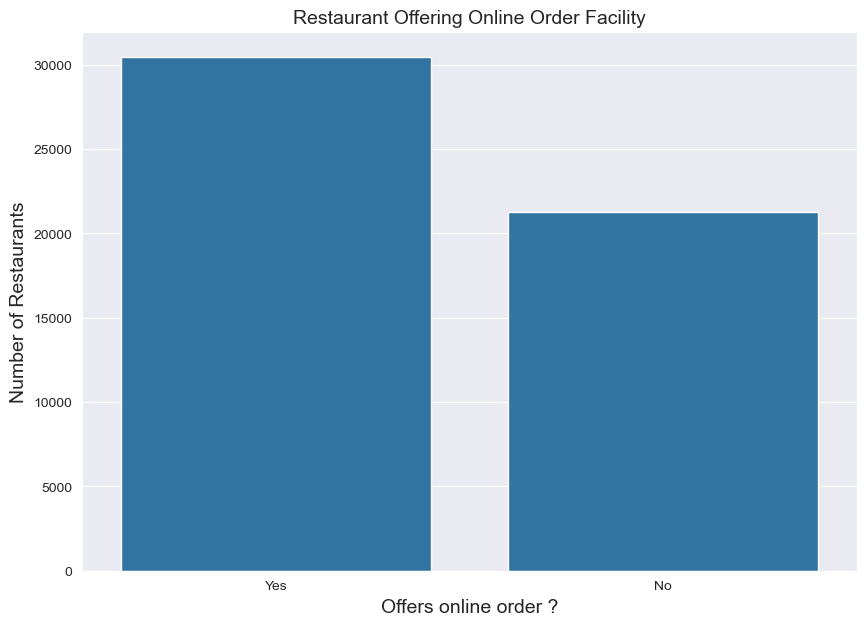

In [46]:
sns.countplot(x= "online_order" , data = df1)
plt.title("Restaurant Offering Online Order Facility",fontsize = 14)
plt.xlabel("Offers online order ?", fontsize = 14)
plt.ylabel("Number of Restaurants", fontsize = 14)
plt.show()

## Q) Do restaurant that offer online ordering have better ratings ?

In [47]:
# Box Plot

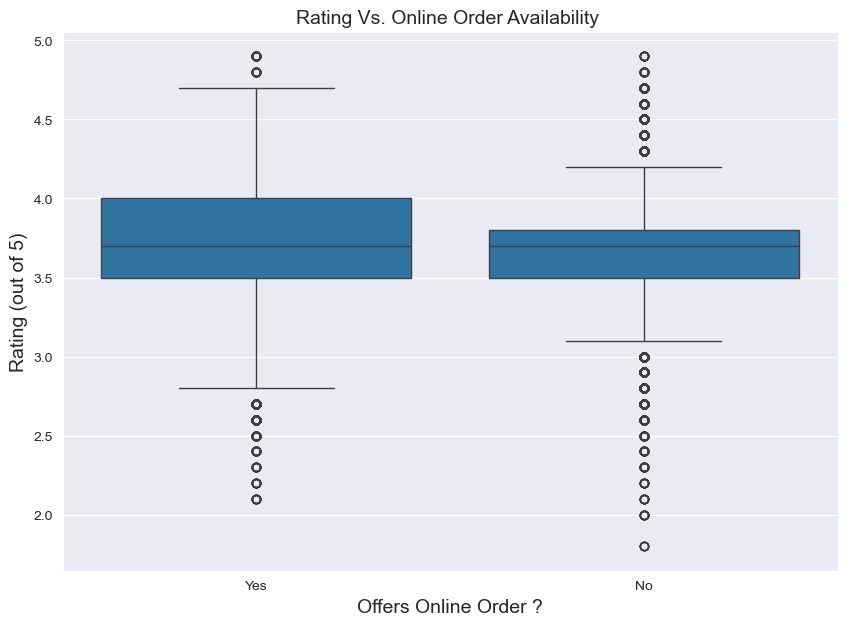

In [48]:
sns.boxplot(x="online_order",y="rate", data= df1)
plt.title("Rating Vs. Online Order Availability ",fontsize = 14)
plt.xlabel("Offers Online Order ?", fontsize = 14)
plt.ylabel("Rating (out of 5)", fontsize = 14)
plt.show()

## Q) What is the relationship b/w Cost and Rating ?

In [49]:
# A jointplot with hexben is great for visualizing dense data.

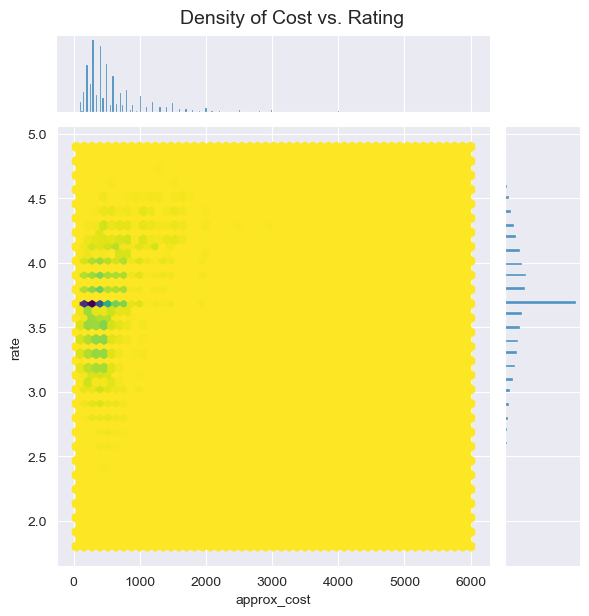

In [52]:
sns.jointplot(x='approx_cost', y = 'rate', data = df1, kind= 'hex', cmap = "viridis_r" )
plt.suptitle("Density of Cost vs. Rating ", y= 1.02, fontsize= 14)
plt.show()

## Q) Does Offering table booking impact ratings?

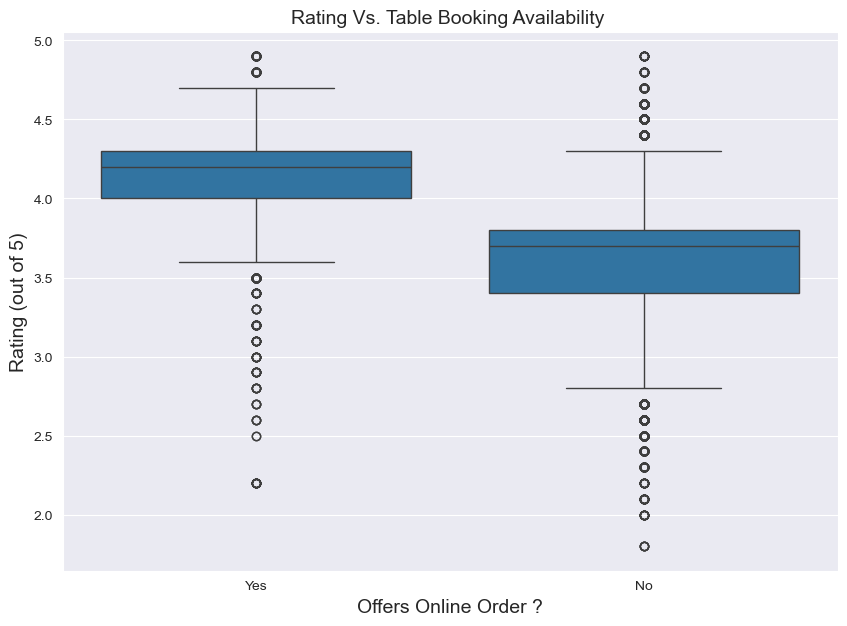

In [54]:
sns.boxplot(x="book_table",y="rate", data= df1)
plt.title("Rating Vs. Table Booking Availability ",fontsize = 14)
plt.xlabel("Offers Online Order ?", fontsize = 14)
plt.ylabel("Rating (out of 5)", fontsize = 14)
plt.show()

## Q) Which restaurant types are most highly rated ?

In [55]:
# To make the Plot readable, lets increase the figure size
# Here since there so many categories so we will Show Average Rating per Restaurant Type.

In [56]:
plt.figure(figsize= (12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

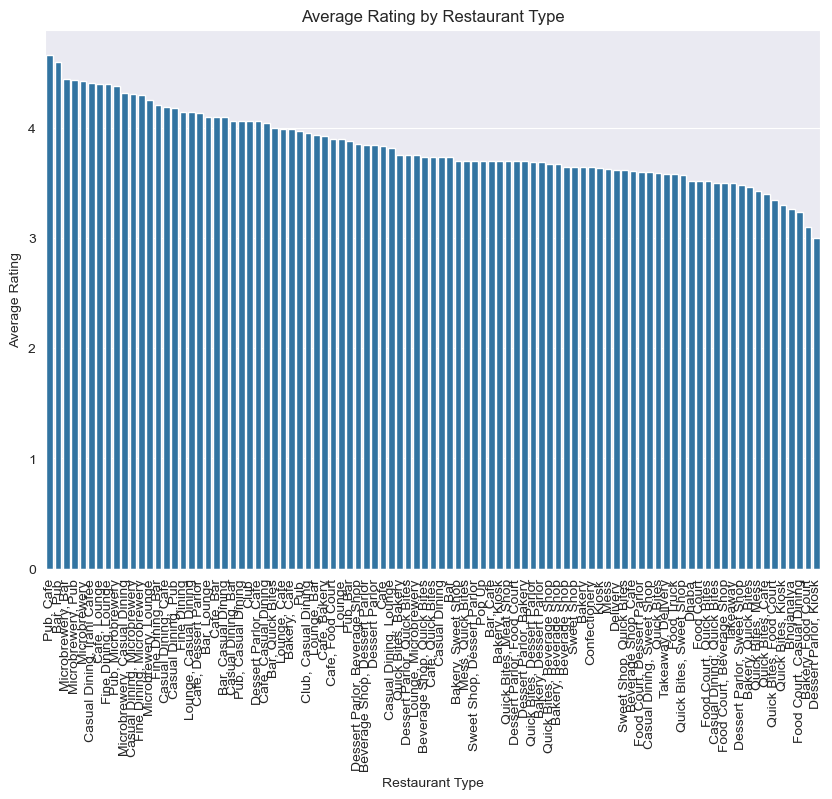

In [60]:
Avg_rating = df1.groupby("rest_type")['rate'].mean().sort_values(ascending = False)

sns.barplot(x=Avg_rating.index, y=Avg_rating.values)
plt.xticks(rotation=90)
plt.title("Average Rating by Restaurant Type")
plt.ylabel("Average Rating")
plt.xlabel("Restaurant Type")
plt.show()

## Q) Which areas have the highest rated restuarant ?

In [62]:
# Area column has too many unique values to plot directly
# Here we will identify the most important areas (let's say the top 15 areas with the most restaurants)
# And then analyze the ratings within that group

C:\Users\Admin\AppData\Local\Temp\ipykernel_16948\1990861213.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='area', y='rate',data= df1_top15, palette ='viridis')


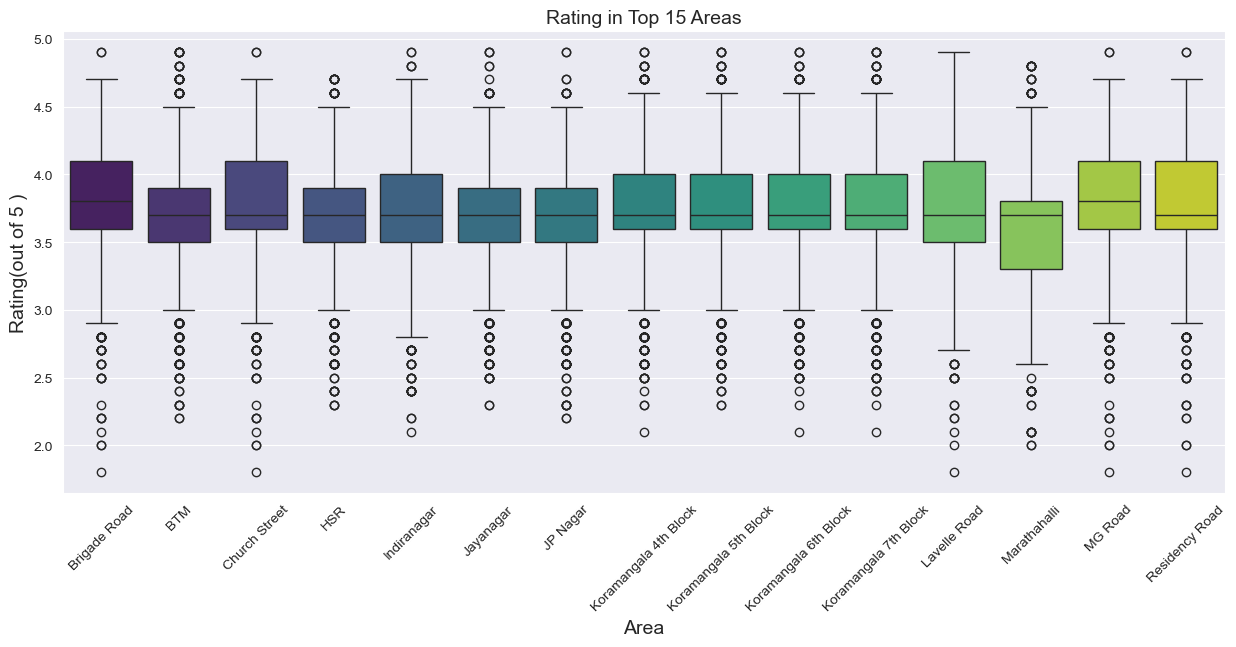

In [68]:
# Top 15 >>>

top_areas = df1['area'].value_counts().nlargest(15).index
df1_top15 = df1[df1['area'].isin(top_areas)]   # Filter the dataFrame to include top 15.

plt.figure(figsize = (15,6))
sns.boxplot(x='area', y='rate',data= df1_top15, palette ='viridis')
plt.title("Rating in Top 15 Areas", fontsize= 14)
plt.xlabel("Area", fontsize= 14)
plt.ylabel("Rating(out of 5 )", fontsize= 14)
plt.xticks(rotation=45)
plt.show()

## Q) What cuisines are a Hit ?

C:\Users\Admin\AppData\Local\Temp\ipykernel_16948\3949169452.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cuisines', y='rate',data= df1_top10, palette ='inferno')


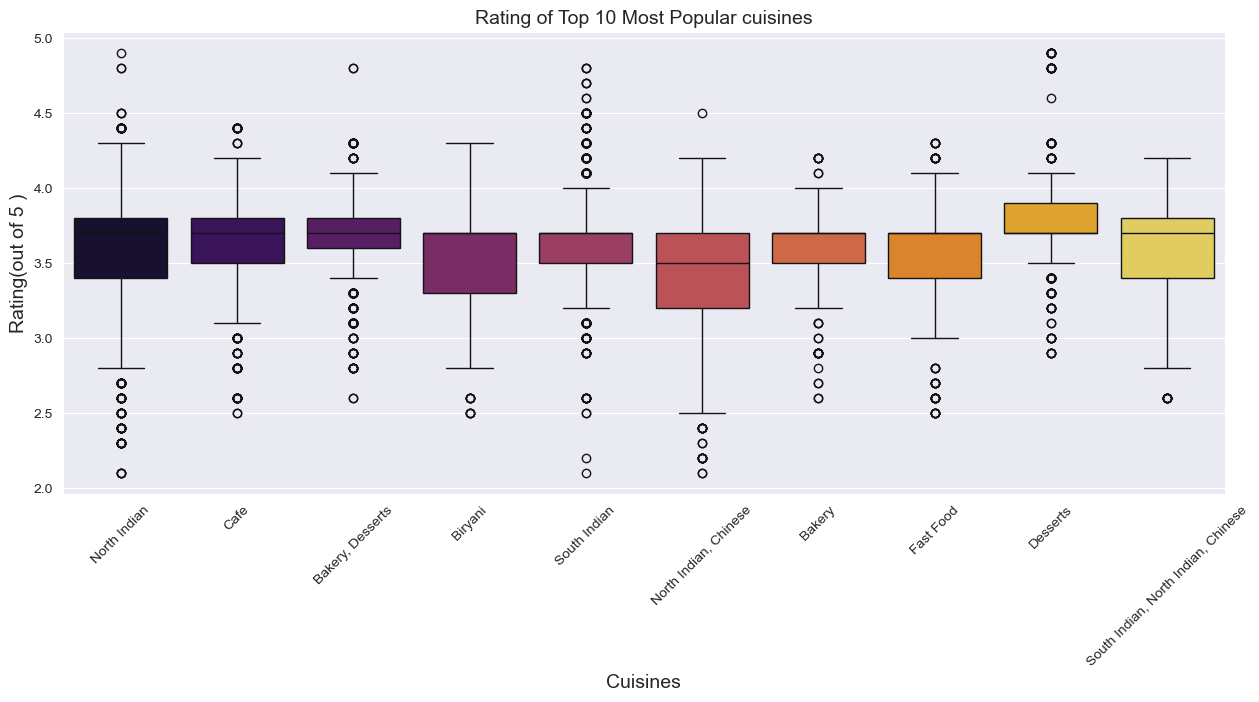

In [73]:
# we will find top 10 most common cuisines 

top_cuisines= df1['cuisines'].value_counts().nlargest(10).index 

# Here will filter dataframe to include only top 10 cuisines

df1_top10= df1[df1["cuisines"].isin(top_cuisines)]

# lets plot the ratings

plt.figure(figsize = (15,6))
sns.boxplot(x='cuisines', y='rate',data= df1_top10, palette ='inferno')
plt.title("Rating of Top 10 Most Popular cuisines", fontsize= 14)
plt.xlabel("Cuisines", fontsize= 14)
plt.ylabel("Rating(out of 5 )", fontsize= 14)
plt.xticks(rotation=45)
plt.show()

In [75]:
df1.to_csv("Zomato_cleaned.csv" , index = False)  # Exported cleaned dataset from Python